In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from disba import PhaseDispersion

In [ ]:
def forward_model(thickness, vp, vp, rho, period):
    # Creates a PhaseDispersion object - gives 1D velocity based on thickness/vs/vp/density
    pd = PhaseDispersion(thickness, vp, vs, rho)
    return pd(period, mode=0, wave="rayleigh")

DispersionCurve(period=array([0.01      , 0.0225641 , 0.03512821, 0.04769231, 0.06025641,
       0.07282051, 0.08538462, 0.09794872, 0.11051282, 0.12307692,
       0.13564103, 0.14820513, 0.16076923, 0.17333333, 0.18589744,
       0.19846154, 0.21102564, 0.22358974, 0.23615385, 0.24871795,
       0.26128205, 0.27384615, 0.28641026, 0.29897436, 0.31153846,
       0.32410256, 0.33666667, 0.34923077, 0.36179487, 0.37435897,
       0.38692308, 0.39948718, 0.41205128, 0.42461538, 0.43717949,
       0.44974359, 0.46230769, 0.47487179, 0.4874359 , 0.5       ]), velocity=array([0.13987896, 0.13996952, 0.14122616, 0.14567554, 0.15616733,
       0.17771198, 0.21157413, 0.24648762, 0.28350559, 0.32617802,
       0.36380527, 0.39113712, 0.41211338, 0.4290369 , 0.44293064,
       0.4544202 , 0.46398594, 0.47201664, 0.47882297, 0.48464847,
       0.48968418, 0.49407657, 0.49793979, 0.50136417, 0.5044199 ,
       0.50716495, 0.5096439 , 0.51189396, 0.51394626, 0.51582584,
       0.51755344, 0.5191479

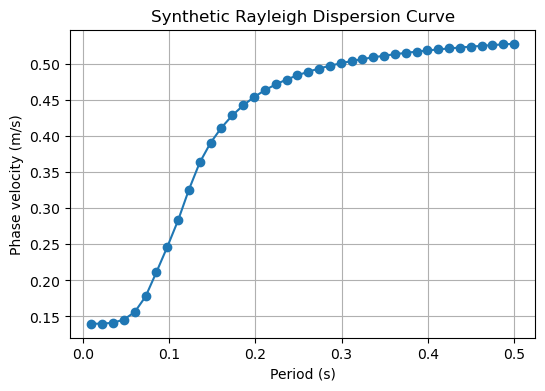

In [30]:
## True model - 2 layers + half-space
# units per disba documentation
# thickness (km)
thickness = [0.005, 0.010, 0]

# s-wave p-wave velocities (km/s)
vs = [.150, .300, 0.600]
vp = [.300, .600, 1.200]
# density (g/cm^3)
rho = [1.8, 1.9, 2.0]
# period[s]
period = np.linspace(0.01, 0.5, 40)

c = forward_model(thickness, vp, vs, rho, period)
print(c)

dobs = c.velocity
T = c.period

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Synthetic Rayleigh Dispersion Curve")
plt.grid(True)
plt.show()

In [32]:
def get_phid(dpred, dobs):
    return np.sum((dpred - dobs)**2)
def get_phim(vs):
    vs = np.array(vs)
    return np.sum(np.diff(vs)**2)

In [31]:
# First Trial
thickness_trial = [0.005, 0.010, 0.0]
vs_trial = [0.180, 0.250, 0.500]

# assume fixed density, p-waves are 2x s-waves (generally true)
vp_trial = [2*v for v in vs_trial]
rho_trial = [1.8, 1.9, 2.0]

trial = forward_model(thickness_trial, vp_trial, vs_trial, rho_trial, period)

In [21]:
# misfit
phid = get_phid(trial.velocity, dobs)
print("Φd =", phid)

# regularization
phim = get_phim(vs_trial)
print("Φm =", phim)

Φd = 0.22338101036298338
Φm = 0.0674


In [39]:
def plot_tikhonov_curves(beta_values, phid, phim, n_data=None, beta_index=0, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].semilogx(beta_values, phid)
    ax[1].semilogx(beta_values, phim)
    ax[2].loglog(phim, phid)

    # highlight chosen beta
    ax[0].semilogx(beta_values[beta_index], phid[beta_index], "ro")
    ax[1].semilogx(beta_values[beta_index], phim[beta_index], "ro")
    ax[2].loglog(phim[beta_index], phid[beta_index], "ro")

    ax[0].set_ylabel(r"$\phi_d$")
    ax[1].set_ylabel(r"$\phi_m$")

    ax[2].set_xlabel(r"$\phi_m$")
    ax[2].set_ylabel(r"$\phi_d$")

    # optional target misfit line
    if n_data is not None:
        ax[0].semilogx(beta_values, np.ones(len(beta_values)) * n_data, "--k")
        ax[2].loglog(phim, np.ones(len(phim)) * n_data, "--k")

    for a in ax[:2]:
        a.invert_xaxis()
        a.set_xlabel(r"$\beta$")

    plt.tight_layout()

In [44]:
def plot_inversion_results(period, dobs, dpreds, vs_true, mrecs, beta_values, beta_index=0, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Panel 1: observed vs predicted dispersion
    ax[0].plot(period, dobs, "o", label="observed data")
    ax[0].plot(period, dpreds[:, beta_index], "-s", label="predicted data")
    ax[0].set_xlabel("Period (s)")
    ax[0].set_ylabel("Phase velocity (km/s)")
    ax[0].set_title(f"Dispersion Curve (beta = {beta_values[beta_index]:.2e})")
    ax[0].legend()
    ax[0].grid(True)

    # Panel 2: true model vs recovered model
    layer_index = np.arange(len(vs_true))
    ax[1].plot(vs_true, layer_index, "o-", label="true model")
    ax[1].plot(mrecs[:, beta_index], layer_index, "s--", label="recovered model")
    ax[1].invert_yaxis()
    ax[1].set_xlabel("Vs (km/s)")
    ax[1].set_ylabel("Layer index")
    ax[1].set_title("True vs Recovered Vs Model")
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()


In [45]:
n_betas = 50
beta_values = np.logspace(6, -6, n_betas)

phid = np.zeros(n_betas)
phim = np.zeros(n_betas)

mrecs = np.zeros((3, n_betas))          # 3-layer Vs model
dpreds = np.zeros((len(period), n_betas))

# fixed
thickness_trial = [0.005, 0.010, 0.0]
rho_trial = [1.8, 1.9, 2.0]

# search space (only vary Vs1 for now)
vs1_candidates = np.linspace(0.10, 0.25, 60)

for i, beta in enumerate(beta_values):
    best_phi = np.inf

    for vs1 in vs1_candidates:
        vs_trial = [vs1, 0.300, 0.600]
        vp_trial = [2 * v for v in vs_trial]

        dpred = forward_model(thickness_trial, vp_trial, vs_trial, rho_trial, period)

        phi_d = get_phid(dpred.velocity, dobs)
        phi_m = get_phim(vs_trial)

        # objective function
        phi = phi_d + beta * phi_m

        if phi < best_phi:
            best_phi = phi
            best_phid = phi_d
            best_phim = phi_m
            best_vs = vs_trial.copy()
            best_dpred = dpred.velocity.copy()

    # store results for this beta
    phid[i] = best_phid
    phim[i] = best_phim
    mrecs[:, i] = best_vs
    dpreds[:, i] = best_dpred

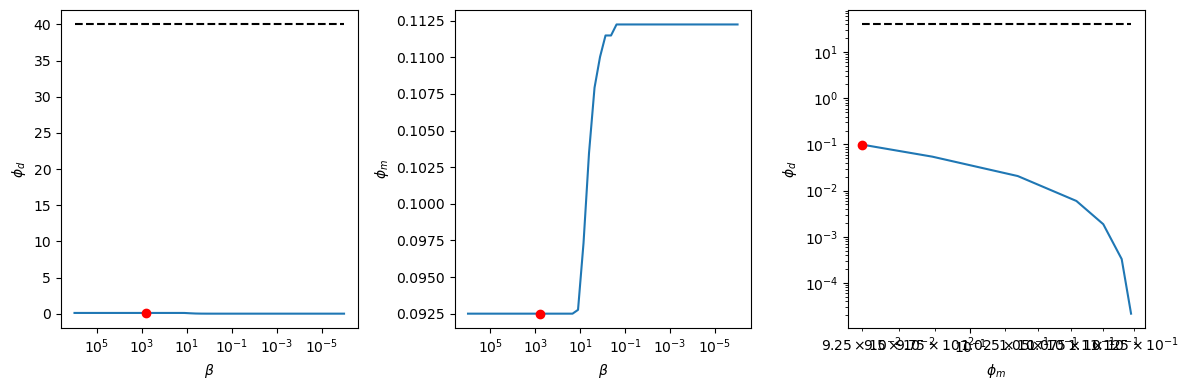

In [46]:
n_data = len(dobs)
z = 13
plot_tikhonov_curves(beta_values, phid, phim, n_data=n_data, beta_index=z)
plt.show()
